In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

import warnings
warnings.filterwarnings('ignore')

In this demo, we explore the datasets in the "raw_data" folder. There are two types of data:

- **Futures data** (multiple contracts with different expiration dates)

- **AI agent trading data**

# **Futures Data**

The futures data contains 6 columns:
$$
[\text{time, open, high, low, close, volume}]
$$

A key feature of futures is that each contract has a fixed expiration date.

- A contract becomes the front contract when it has the highest liquidity.

- Before becoming the front contract, its volume is very low.

- As it approaches expiration, volume drops sharply as traders roll to the next contract.

For example, the Nasdaq contract NQH20 (March 2020) has high volume roughly from mid-Dec 2019 to mid-Mar 2020, when it is the front contract. Outside this period, trading activity is negligible.

Since multiple contracts with different expiration dates coexist, we need to identify the front-contract period for each contract and stitch these periods together to form a continuous time series.

Therefore, the data cleaning involves two main steps:

- **Remove illiquid periods** for each contract (low volume / low activity)

- **Combine front-contract periods** across contracts to construct a consistent series

### **Special Case: Heating Oil**

Heating Oil futures present additional challenges:

- Contracts are listed monthly, leading to more frequenc rollovers.

- Identifying the front contract is less clear.

- Some contracts exhibit abnormal early volume (e.g. HOM22 has high volume as early as Oct 2020, far from its June 2022 expiration).

This makes contract selection and filtering more difficult compared to other assets.

,time,open,high,low,close,volume
104531,2020-03-20 09:25:00,7437.25,7445.75,7432.00,7432.00,10.0
104532,2020-03-20 09:26:00,7438.75,7447.50,7433.75,7437.75,66.0
104533,2020-03-20 09:27:00,7445.00,7445.00,7365.00,7368.50,17.0
104534,2020-03-20 09:28:00,7368.00,7439.00,7368.00,7439.00,13.0
104535,2020-03-20 09:29:00,7450.00,7453.50,7370.00,7453.50,55.0


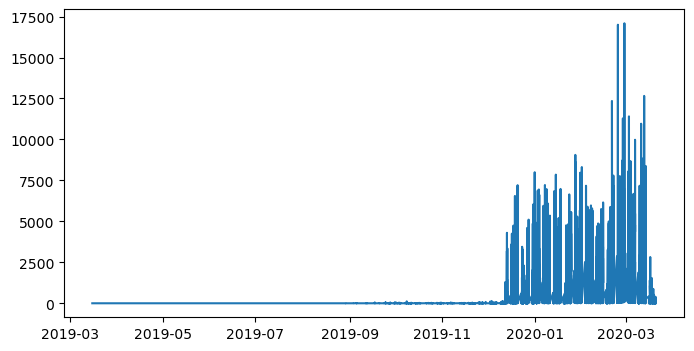

In [6]:
sample_data=pd.read_csv(RAW_DATA_DIR/'Nasdaq'/'NQH20.csv',header=None)
sample_data.columns=['time','open','high','low','close','volume']
sample_data['time']=pd.to_datetime(sample_data['time'])
sample_data[['open','high','low','close','volume']]=sample_data[['open','high','low','close','volume']].astype(float)

plt.figure(figsize=(8,4))
plt.plot(sample_data['time'],sample_data['volume'])
plt.plot()

sample_data.tail()

,time,open,high,low,close,volume
72723,2022-05-31 14:25:00,404.08,407.77,403.48,403.48,7.0
72724,2022-05-31 14:26:00,403.75,404.50,403.75,404.50,2.0
72725,2022-05-31 14:27:00,404.50,405.33,404.50,404.50,7.0
72726,2022-05-31 14:28:00,403.34,403.41,402.43,402.76,17.0
72727,2022-05-31 14:29:00,400.00,400.06,398.94,398.94,12.0


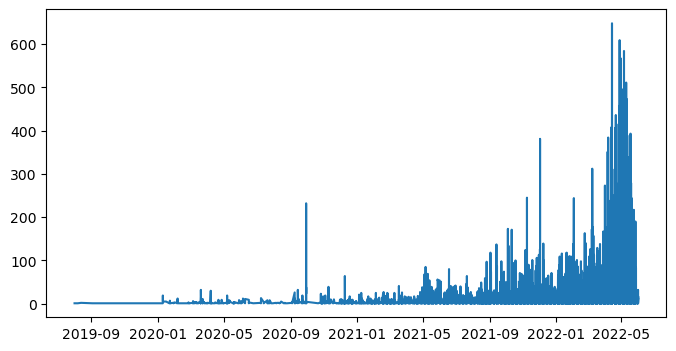

In [11]:
sample_data=pd.read_csv(RAW_DATA_DIR/'HeatingOil'/'HOM22.csv',header=None)
sample_data.columns=['time','open','high','low','close','volume']
sample_data['time']=pd.to_datetime(sample_data['time'])
sample_data[['open','high','low','close','volume']]=sample_data[['open','high','low','close','volume']].astype(float)

plt.figure(figsize=(8,4))
plt.plot(sample_data['time'],sample_data['volume'])
plt.plot()

sample_data.tail()

# **AI Agent Data**

The AI agent data contains 5 columns:
$$
[\text{date, hour, minute, price, position}]
$$

Interpretation:

- At each timestamp, the agent observes a price and holds a net position (inventory). 

- The "date" column may appear as integers (e.g. 43832) due to Excel/CSV formatting issues.


### **PnL Construction:**

we can reconstruct the agent's PnL from position changes. Let:

- $p_1$: price at time $t$

- $p_2$: price at time $t+\delta t$

If position changes from $q_1$ to $q_2$:

- $q_2>q_1$: agent buys $q_2-q_1$ units

- $q_2>q_1$: agent sells $q_1-q_2$ units

But the exact execution pride is unknown. For example:

- At 2:25, $p_1​=8795.25$, position=0

- At 2:30, $p_2​=8795.00$, position=3

This implies the agent bought 3 units during this interval, but the execution price is unobserved.

We consider three approximations:

- Use $p_1$: assumes immediate execution at the beginning of the interval

- Use $p_2$: assumes execution at the end of the interval

- Use $(p_1+p_2)/2$: ssumes execution uniformly within the interval

In this project, we will choose one approximation (e.g. $p_2$) for consistency.


**PnL Calculation:**

Define cash account $C_t$ and position $q_t$.

The traded quantity is:
$$
\delta q_t = q_t - q_{t-1}
$$

Cash evolves as:
$$
C_t = C_{t-1} - \delta q_t \cdot p_t
$$
- Buying ($\delta q_t>0$) reduces cash
- Selling ($\delta q_t<0$) increases cash

The mark-to-market PnL is:
$$
\text{PnL}_t = C_t+q_t \cdot p_t
$$

In [10]:
sample_data=pd.read_csv(RAW_DATA_DIR/'Nasdaq'/'AIAgent_Nasdaq.csv',header=None)
sample_data.columns=['date','hour','minute','price','position']
sample_data['date']=pd.to_datetime(sample_data['date'], unit='D', origin='1899-12-30')

sample_data.iloc[25:35]

,date,hour,minute,price,position
25,2020-01-02,2,5,8790.00,0
26,2020-01-02,2,10,8791.25,0
27,2020-01-02,2,15,8790.50,0
28,2020-01-02,2,20,8794.50,0
29,2020-01-02,2,25,8795.25,0
30,2020-01-02,2,30,8795.00,3
31,2020-01-02,2,35,8794.75,3
32,2020-01-02,2,40,8795.50,3
33,2020-01-02,2,45,8796.25,3
34,2020-01-02,2,50,8798.25,3


# **Time Converage**

We need to figure out whether raw futures data covers all the timestamps in the agent data. If yes, it's ok and makes things eaiser. If not, we need to find the missing period and find the intersection.

In [39]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
print(f'All Markets: {markets}')
print(f'Number of markets: {len(markets)}')

for market in markets:
    print(f'========== {market} ==========')
    market_path=RAW_DATA_DIR/market
    
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
    
    # futures_data
    futures_data=[]
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value, this doesn't change the results here
        data.columns=['time','open','high','low','close','volume']
        data=data.sort_values('time')
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=6) # change from calendar days to trading days
        data.set_index('time',inplace=True)
        volume_seris=data['volume']
        volume_seris.name=file[:-4]
        futures_data.append(volume_seris)
        
    futures_data=pd.concat(futures_data,axis=1,join='outer')
    futures_data.reset_index(inplace=True)
    futures_data['time']=pd.to_datetime(futures_data['time'])
    futures_data['date']=pd.to_datetime(futures_data['time'].dt.date)
    
    # AI agent data
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                    + pd.to_timedelta(ai_data['hour'], unit='h') 
                    + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=6)
    
    # time intersection: minute
    print('Minute timestamp:')
    futures_data=futures_data[(futures_data['time']>=ai_data['time'].iloc[0])&
                              (futures_data['time']<=ai_data['time'].iloc[-1])]
    futures_timestamp=set(list(futures_data['time'].values))
    agent_timestamp=set(list(ai_data['time'].values))
    if agent_timestamp.issubset(futures_timestamp):
        print('agent_time is a subset of futures_time: 100% coverage!')
    elif futures_timestamp.issubset(agent_timestamp):
        print('futures_time is a subset of agent_time: very abnormal')
        missing_timestamp=agent_timestamp-futures_timestamp
        missing_pct=len(missing_timestamp)/len(agent_timestamp)
        print(f'Missing pct = {missing_pct:.4f}')
    else:
        if futures_timestamp.intersection(agent_timestamp):
            print('futures_time and agent_time overlap, but neither is a subset of the other ')
            missing_timestamp=agent_timestamp-futures_timestamp
            missing_pct=len(missing_timestamp)/len(agent_timestamp)
            print(f'Missing pct = {missing_pct:.4f}')
        else:
            print("futures_time and agent_time don't overlap")
        
    # time intersection: daily
    print('Daily timestamp:')
    futures_data=futures_data[(futures_data['date']>=ai_data['date'].iloc[0])&
                              (futures_data['date']<=ai_data['date'].iloc[-1])]
    futures_timestamp=set(list(futures_data['date'].values))
    agent_timestamp=set(list(ai_data['date'].values))
    if agent_timestamp.issubset(futures_timestamp):
        print('agent_time is a subset of futures_time: 100% coverage!')
    elif futures_timestamp.issubset(agent_timestamp):
        print('futures_time is a subset of agent_time: very abnormal')
        missing_timestamp=agent_timestamp-futures_timestamp
        missing_pct=len(missing_timestamp)/len(agent_timestamp)
        print(f'Missing pct = {missing_pct:.4f}')
    else:
        if futures_timestamp.intersection(agent_timestamp):
            print('futures_time and agent_time overlap, but neither is a subset of the other ')
            missing_timestamp=agent_timestamp-futures_timestamp
            missing_pct=len(missing_timestamp)/len(agent_timestamp)
            print(f'Missing pct = {missing_pct:.4f}')
        else:
            print("futures_time and agent_time don't overlap")
        
        

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
========== EuroStoxx ==========
Minute timestamp:
futures_time and agent_time overlap, but neither is a subset of the other 
Missing pct = 0.1773
Daily timestamp:
futures_time is a subset of agent_time: very abnormal
Missing pct = 0.1860
========== GBP - British Pound ==========
Minute timestamp:
futures_time and agent_time overlap, but neither is a subset of the other 
Missing pct = 0.2222
Daily timestamp:
futures_time is a subset of agent_time: very abnormal
Missing pct = 0.2788
========== German Bunds - German Government Bonds ==========
Minute timestamp:
futures_time and agent_time overlap, but neither is a subset of the other 
Missing pct = 0.2717
Daily timestamp:
futures_time is a subset of agent_time: very abnormal
Missing pct = 0.1628
========== Gold ==========
Minute timestamp:
futures_time and agent_time overlap

In [40]:
raw_data_path=RAW_DATA_DIR
market='Nasdaq'

market_path=raw_data_path/market

files=sorted([p.name for p in market_path.glob("*.csv")
            if not p.name.startswith("AIAgent")])
ai_file=[p.name for p in market_path.glob("*.csv")
            if p.name.startswith("AIAgent")][0]

# futures_data
futures_data=[]
for file in files:
    data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
    data=data.dropna() # delete rows with missing value, this doesn't change the results here
    data.columns=['time','open','high','low','close','volume']
    data=data.sort_values('time')
    data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
    data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=6) # change from calendar days to trading days
    data.set_index('time',inplace=True)
    volume_seris=data['volume']
    volume_seris.name=file[:-4]
    futures_data.append(volume_seris)
    
futures_data=pd.concat(futures_data,axis=1,join='outer')
futures_data.reset_index(inplace=True)
futures_data['time']=pd.to_datetime(futures_data['time'])
futures_data['date']=pd.to_datetime(futures_data['time'].dt.date)

# AI agent data
ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
ai_data.columns=['date','hour','minute','price','position']
ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
ai_data['time'] = (ai_data['date']
                + pd.to_timedelta(ai_data['hour'], unit='h') 
                + pd.to_timedelta(ai_data['minute'], unit='m'))
ai_data['time']=ai_data['time']+pd.Timedelta(hours=6)
ai_data['trade']=ai_data['position'].diff().abs()

In [41]:
import yfinance as yf

spx = yf.download(
    "^SPX",
    start="2016-01-01",
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

spx.columns = spx.columns.get_level_values(0)
spx = spx[['Close']].rename(columns={'Close': 'spx'})
spx.reset_index(inplace=True)
spx.columns.name=None
spx.columns=['date','spx']
spx['date']=pd.to_datetime(spx['date'])
spx.head()

,date,spx
0,2016-01-04,2012.660034
1,2016-01-05,2016.709961
2,2016-01-06,1990.260010
3,2016-01-07,1943.089966
4,2016-01-08,1922.030029


In [58]:
ai_daily=ai_data.groupby('date')['trade'].sum().reset_index()
ai_daily['date']=pd.to_datetime(ai_daily['date'])

futures_daily=futures_data.groupby('date')['time'].count().reset_index()
futures_daily['date']=pd.to_datetime(futures_daily['date'])
futures_daily=futures_daily[(futures_daily['date']>=ai_daily['date'].iloc[0])&
                            (futures_daily['date']<=ai_daily['date'].iloc[-1])]

index_df=spx[(spx['date']>=ai_daily['date'].iloc[0])&
             (spx['date']<=ai_daily['date'].iloc[-1])]

index_dates=set(list(index_df['date'].values))
ai_dates=set(list(ai_daily['date'].values))
if index_dates.issubset(ai_dates):
    print('index_dates is a subset of ai_dates')
    print('This means ai_dates contains weekends or holidays')
    temp=ai_daily[ai_daily['date'].isin(list(ai_dates-index_dates))]
    temp['weekday']=temp['date'].dt.day_name()
    holiday_trade=temp[~temp['weekday'].isin(['Saturday','Sunday'])]['trade'].sum()
    weekend_trade=temp[temp['weekday'].isin(['Saturday','Sunday'])]['trade'].sum()
    print(f'Traded during holidays: {holiday_trade}')
    print(f'Traded during weekends: {weekend_trade}')
    holiday_num=temp[~temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
    weekend_num=temp[temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
    print(f'Number of holidays: {holiday_num}')
    print(f'Number of weekends: {weekend_num}')
    
    ai_daily=ai_daily.set_index('date')
    ai_daily=ai_daily.loc[list(index_dates)]
    ai_daily=ai_daily.sort_index()
    
    futures_dates=set(list(futures_daily['date'].values))
    if futures_dates == index_dates:
        print('futures_dates is equal to index_dates')
    elif futures_dates.issubset(index_dates):
        print(f'futures_dates is a subset of index_dates, there are missing trading days of futures data')
    elif index_dates.issubset(futures_dates):
        print('index_dates is a subset of futures_dates')
        print('This means futures_dates also contains weekends or holidays')
        
        temp=futures_daily[futures_daily['date'].isin(list(futures_dates-index_dates))]
        temp['weekday']=temp['date'].dt.day_name()
        holiday_num=temp[~temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
        weekend_num=temp[temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
        print(f'Number of holidays: {holiday_num}')
        print(f'Number of weekends: {weekend_num}')
        
        
    else:
        print('other reasons')
else:
    print('Other reasons')


index_dates is a subset of ai_dates
This means ai_dates contains weekends or holidays
Traded during holidays: 95.0
Traded during weekends: 0.0
Number of holidays: 4
Number of weekends: 22
index_dates is a subset of futures_dates
This means futures_dates also contains weekends or holidays
Number of holidays: 3
Number of weekends: 0


In [61]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
print(f'All Markets: {markets}')
print(f'Number of markets: {len(markets)}')

for market in markets:
    print(f'========== {market} ==========')
    market_path=raw_data_path/market
    
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
    
    # futures_data
    futures_data=[]
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value, this doesn't change the results here
        data.columns=['time','open','high','low','close','volume']
        data=data.sort_values('time')
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=6) # change from calendar days to trading days
        data.set_index('time',inplace=True)
        volume_seris=data['volume']
        volume_seris.name=file[:-4]
        futures_data.append(volume_seris)
        
    futures_data=pd.concat(futures_data,axis=1,join='outer')
    futures_data.reset_index(inplace=True)
    futures_data['time']=pd.to_datetime(futures_data['time'])
    futures_data['date']=pd.to_datetime(futures_data['time'].dt.date)
    
    
    # AI agent data
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data=ai_data.dropna()
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                    + pd.to_timedelta(ai_data['hour'], unit='h') 
                    + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=6)
    ai_data['trade']=ai_data['position'].diff().abs()
    
    
    
    ai_daily=ai_data.groupby('date')['trade'].sum().reset_index()
    ai_daily['date']=pd.to_datetime(ai_daily['date'])

    futures_daily=futures_data.groupby('date')['time'].count().reset_index()
    futures_daily['date']=pd.to_datetime(futures_daily['date'])
    futures_daily=futures_daily[(futures_daily['date']>=ai_daily['date'].iloc[0])&
                                (futures_daily['date']<=ai_daily['date'].iloc[-1])]

    index_df=spx[(spx['date']>=ai_daily['date'].iloc[0])&
                (spx['date']<=ai_daily['date'].iloc[-1])]

    index_dates=set(list(index_df['date'].values))
    ai_dates=set(list(ai_daily['date'].values))
    if index_dates.issubset(ai_dates):
        print('index_dates is a subset of ai_dates')
        print('This means ai_dates contains weekends or holidays')
        temp=ai_daily[ai_daily['date'].isin(list(ai_dates-index_dates))]
        temp['weekday']=temp['date'].dt.day_name()
        holiday_trade=temp[~temp['weekday'].isin(['Saturday','Sunday'])]['trade'].sum()
        weekend_trade=temp[temp['weekday'].isin(['Saturday','Sunday'])]['trade'].sum()
        print(f'Traded during holidays: {holiday_trade}')
        print(f'Traded during weekends: {weekend_trade}')
        holiday_num=temp[~temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
        weekend_num=temp[temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
        print(f'Number of holidays: {holiday_num}')
        print(f'Number of weekends: {weekend_num}')
        
        ai_daily=ai_daily.set_index('date')
        ai_daily=ai_daily.loc[list(index_dates)]
        ai_daily=ai_daily.sort_index()
        
        futures_dates=set(list(futures_daily['date'].values))
        if futures_dates == index_dates:
            print('futures_dates is equal to index_dates')
        elif futures_dates.issubset(index_dates):
            print(f'futures_dates is a subset of index_dates, there are missing trading days of futures data')
        elif index_dates.issubset(futures_dates):
            print('index_dates is a subset of futures_dates')
            print('This means futures_dates also contains weekends or holidays')
            
            temp=futures_daily[futures_daily['date'].isin(list(futures_dates-index_dates))]
            temp['weekday']=temp['date'].dt.day_name()
            holiday_num=temp[~temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
            weekend_num=temp[temp['weekday'].isin(['Saturday','Sunday'])].shape[0]
            print(f'Number of holidays: {holiday_num}')
            print(f'Number of weekends: {weekend_num}')
        else:
            print('futures_dates contains holidays or weekends, and it also has missing trading dates.')
    else:
        print('Other reasons')

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
========== EuroStoxx ==========
index_dates is a subset of ai_dates
This means ai_dates contains weekends or holidays
Traded during holidays: 10.0
Traded during weekends: 0.0
Number of holidays: 4
Number of weekends: 22
futures_dates contains holidays or weekends, and it also has missing trading dates.
========== GBP - British Pound ==========
index_dates is a subset of ai_dates
This means ai_dates contains weekends or holidays
Traded during holidays: 53.0
Traded during weekends: 0.0
Number of holidays: 2
Number of weekends: 17
futures_dates contains holidays or weekends, and it also has missing trading dates.
========== German Bunds - German Government Bonds ==========
index_dates is a subset of ai_dates
This means ai_dates contains weekends or holidays
Traded during holidays: 45.0
Traded during weekends: 0.0
Number of h